In [1]:
import matplotlib.pyplot as plt
import torch
import torchvision.transforms as transforms
import gc
import logging
from components.other_utilities.models_to_train import ResNetPLModel
from components.FL_sim import FLSimulator
from components.other_utilities.datasets import FasterSVHN
from components.FL_sim import Agent
from components.FL_sim import FederatedModelWrapper
torch.set_float32_matmul_precision('high')

dataset = [
    FasterSVHN(
        root='../data/SVHN', split=s,
        transform=transforms.Compose([
            transforms.Resize(32),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.4377, 0.4438, 0.4728],
                std=[0.1980, 0.2010, 0.1970]
            ),
        ])
    ) for s in ['train', 'test']]

# dataset = [torch.utils.data.Subset(d, list(range(2000))) for d in dataset]
# for i in range(10):
#     for d in dataset:
#         d.dataset.labels[i] = i

def pre_send_process(worker_grad_dict, agent_id):
    worker_broadcast_data = [worker_grad_dict]
    return worker_broadcast_data


def server_rec_process(worker_broadcast_data, agent_id, worker_count, global_model_dims, previous_data, ):
    # use this function to process the data received from workers
    result_dict = worker_broadcast_data[0]
    return result_dict


k = 2
batch_size = 5000
logging_disabled = True
post_training_report = False

In [2]:
state_data_samples_per_batch_list_w1 = []

corr_per_batch_list = []

middle_non_z_col = None

def compute_corr_quantile(grads_samples_1, grads_samples_2, n_quantiles=10):
    # sort rows by the middle column
    grads_samples_1 = grads_samples_1.to(torch.float32)
    grads_samples_2 = grads_samples_2.to(torch.float32)

    global middle_non_z_col
    if middle_non_z_col is None:
        for a in grads_samples_1[:, (grads_samples_1.shape[1]*4)//10:].T:
            if not torch.all(a == 0):
                middle_non_z_col = a.nonzero(as_tuple=True)[0]
                break
        else:
            raise ValueError("No non-zero column found in the second half of the samples.")

    grads_samples_1 = grads_samples_1[grads_samples_1[:, middle_non_z_col[0]].argsort()]
    grads_samples_2 = grads_samples_2[grads_samples_2[:, middle_non_z_col[1]].argsort()]

    mean1 = grads_samples_1.mean(dim=0, keepdim=True)
    mean2 = grads_samples_2.mean(dim=0, keepdim=True)

    centered1 = grads_samples_1 - mean1
    centered2 = grads_samples_2 - mean2

    # Compute covariance and variances in one pass
    covariance = (centered1 * centered2).mean(dim=0)
    var1 = (centered1 ** 2).mean(dim=0)
    var2 = (centered2 ** 2).mean(dim=0)

    # Pearson correlation coefficient
    correlation = covariance / (torch.sqrt(var1 * var2) + 1e-8)
    correlation = torch.where(torch.isnan(correlation), torch.zeros_like(correlation), correlation)

    corr_per_batch_list.append(correlation.to(torch.float16))


class CorrAgent(Agent):
    def train(self, train_dataloader, test_dataloader, epochs, round_s):
        assert isinstance(self.local_model, FederatedModelWrapper), \
            "Local model is not set. Call set_local_models() before training."

        self.local_model.args_for_f_on_grad['curr_round'] = round_s

        # load model to GPU memory
        self.local_model.train()
        self.local_model.to('cuda')

        self.local_model.optimizer = self.local_model.configure_optimizers()

        # train the model manually
        self.local_model.on_train_start()

        for epoch in range(epochs):
            for batch_idx, (data, target) in enumerate(train_dataloader):
                print(f'          >> {epoch=}, batch_idx= {batch_idx+1}/{len(train_dataloader)}')

                pre_sample_checkpoint = self.local_model.state_dict()
                current_accu_param_grads = {k:v.clone() for k, v in self.local_model.accu_param_grads.items()}
                # make samples
                samples = []
                for i in range(30):
                    self.local_model.load_state_dict(pre_sample_checkpoint)
                    self.local_model.accu_param_grads = current_accu_param_grads

                    self.local_model.optimizer.zero_grad()

                    loss = self.local_model.training_step((data.to('cuda'), target.to('cuda')), batch_idx)
                    loss.backward()

                    self.local_model.on_before_optimizer_step(self.local_model.optimizer)

                    self.local_model.optimizer.step()

                    # record samples of grads
                    samples.append(
                        torch.concatenate([v.to(torch.float16).cpu().clone().flatten()
                         for k, v in self.local_model.accu_param_grads.items()])
                    )
                samples = torch.stack(samples, dim=0)

                if self.agent_id==0:
                    state_data_samples_per_batch_list_w1.append(samples)
                if self.agent_id == 1:
                    compute_corr_quantile(
                        state_data_samples_per_batch_list_w1.pop(0).to('cuda'),
                        samples.to('cuda'),)

        # remove model from GPU memory
        self.local_model.eval()
        self.local_model.to('cpu')

        gc.collect()
        torch.cuda.empty_cache()

class CorrFLSimulator(FLSimulator):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.agents = [
            CorrAgent(agent_id, self.train_sampler.size_of_partition[agent_id], pre_send_process)
            for agent_id in range(len(self.agents))
        ]


In [3]:
model = ResNetPLModel(num_classes=10, resnet_version='resnet18', lr=0.01, logging_disabled=logging_disabled)

model.load_state_dict(torch.load('exp_data/resnet18_svhn.pth', map_location='cpu'))

sim = CorrFLSimulator(
    num_agents=k, communication_rounds=1, client_epochs_per_round=3,
    batch_size=batch_size, dataset_train=dataset[0], dataset_test=dataset[1],
    aggregation_method='fedavg', non_iid_sampling=False, pl_model=model,
    pre_send_process=pre_send_process, server_rec_process=server_rec_process
)

logging.getLogger("pytorch_lightning").setLevel(logging.WARNING)
sim.run_simulation(post_training_report=post_training_report, pre_training_global_epochs=0)


round 1/1 --------------------
  - reporting global model metrics
         test loss: 2.168, test auc: 0.614
         train loss: (rank='ALL') 2.182, train auc: 0.612
     > training agent 1/2
          >> epoch=0, batch_idx= 1/8
          >> epoch=0, batch_idx= 2/8
          >> epoch=0, batch_idx= 3/8
          >> epoch=0, batch_idx= 4/8
          >> epoch=0, batch_idx= 5/8
          >> epoch=0, batch_idx= 6/8
          >> epoch=0, batch_idx= 7/8
          >> epoch=0, batch_idx= 8/8
          >> epoch=1, batch_idx= 1/8
          >> epoch=1, batch_idx= 2/8
          >> epoch=1, batch_idx= 3/8
          >> epoch=1, batch_idx= 4/8
          >> epoch=1, batch_idx= 5/8
          >> epoch=1, batch_idx= 6/8
          >> epoch=1, batch_idx= 7/8
          >> epoch=1, batch_idx= 8/8
          >> epoch=2, batch_idx= 1/8
          >> epoch=2, batch_idx= 2/8
          >> epoch=2, batch_idx= 3/8
          >> epoch=2, batch_idx= 4/8
          >> epoch=2, batch_idx= 5/8
          >> epoch=2, batch_i

OutOfMemoryError: CUDA out of memory. Tried to allocate 1.25 GiB. GPU 0 has a total capacity of 11.99 GiB of which 8.27 GiB is free. Of the allocated memory 2.06 GiB is allocated by PyTorch, and 465.60 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

(0.0, 1.0)

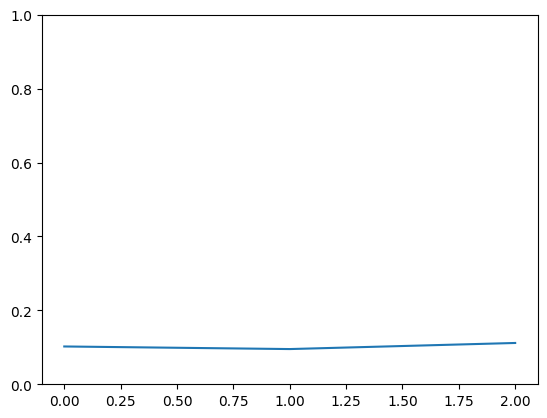

In [11]:
temp = torch.stack(corr_per_batch_list).abs().mean(dim=1)
plt.plot(temp.cpu().numpy())
plt.ylim(0, 1)